
# ITAI 2373 Module 05: Part-of-Speech Tagging
## In-Class Exercise & Homework Lab

Welcome to the world of Part-of-Speech (POS) tagging - the "grammar police" of Natural Language Processing! 🚔📝

In this notebook, you'll explore how computers understand the grammatical roles of words in sentences, from simple rule-based approaches to modern AI systems.

### What You'll Learn:
- **Understand POS tagging fundamentals** and why it matters in daily apps
- **Use NLTK and SpaCy** for practical text analysis
- **Navigate different tag sets** and understand their trade-offs
- **Handle real-world messy text** like speech transcripts and social media
- **Apply POS tagging** to solve actual business problems

### Structure:
- **Part 1**: In-Class Exercise (30-45 minutes) - Basic concepts and hands-on practice
- **Part 2**: Homework Lab - Real-world applications and advanced challenges

---

*💡 **Pro Tip**: POS tagging is everywhere! It helps search engines understand "Apple stock" vs "apple pie", helps Siri understand your commands, and powers autocorrect on your phone.*



## 🛠️ Setup and Installation

Let's get our tools ready! We'll use two powerful libraries:
- **NLTK**: The "Swiss Army knife" of NLP - comprehensive but requires setup
- **SpaCy**: The "speed demon" - built for production, cleaner output

Run the cells below to install and set up everything we need.


In [32]:

# Install required libraries (run this first!)
!pip install nltk spacy matplotlib seaborn pandas
!python -m spacy download en_core_web_sm

print("✅ Installation complete!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 57.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Installation complete!


In [33]:

# Import all the libraries we'll need
import nltk
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data (this might take a moment)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('universal_tagset')

# Load SpaCy model
nlp = spacy.load('en_core_web_sm')

print("🎉 All libraries loaded successfully!")
print("📚 NLTK version:", nltk.__version__)
print("🚀 SpaCy version:", spacy.__version__)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


🎉 All libraries loaded successfully!
📚 NLTK version: 3.9.1
🚀 SpaCy version: 3.8.11



---
# 🎯 PART 1: IN-CLASS EXERCISE (30-45 minutes)

Welcome to the hands-on portion! We'll start with the basics and build up your understanding step by step.

## Learning Goals for Part 1:
1. Understand what POS tagging does
2. Use NLTK and SpaCy for basic tagging
3. Interpret and compare different tag outputs
4. Explore word ambiguity with real examples
5. Compare different tagging approaches



## 🔍 Activity 1: Your First POS Tags (10 minutes)

Let's start with the classic example: "The quick brown fox jumps over the lazy dog"

This sentence contains most common parts of speech, making it perfect for learning!


In [34]:

# Let's start with a classic example
sentence = "The quick brown fox jumps over the lazy dog"

# TODO: Use NLTK to tokenize and tag the sentence
# Hint: Use nltk.word_tokenize() and nltk.pos_tag()
tokens = nltk.word_tokenize(sentence)
pos_tags = nltk.pos_tag(tokens)

print("Original sentence:", sentence)
print("\nTokens:", tokens)
print("\nPOS Tags:")
for word, tag in pos_tags:
    print(f"  {word:8} -> {tag}")


Original sentence: The quick brown fox jumps over the lazy dog

Tokens: ['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']

POS Tags:
  The      -> DT
  quick    -> JJ
  brown    -> NN
  fox      -> NN
  jumps    -> VBZ
  over     -> IN
  the      -> DT
  lazy     -> JJ
  dog      -> NN



### 🤔 Quick Questions:
1. What does 'DT' mean? What about 'JJ'?
2. Why do you think 'brown' and 'lazy' have the same tag?
3. Can you guess what 'VBZ' represents?

*Hint: Think about the grammatical role each word plays in the sentence!*

1. 'DT' means that the word serves as a determiner, while 'JJ' means that the word is an adjective.
2. The words 'brown' and 'lazy' have the same tag, because they are of the same type: adjectives.
3. VBZ means that the word is a verb.


## 🚀 Activity 2: SpaCy vs NLTK Showdown (10 minutes)

Now let's see how SpaCy handles the same sentence. SpaCy uses cleaner, more intuitive tag names.


In [35]:

# TODO: Process the same sentence with SpaCy
# Hint: Use nlp(sentence) and access .text and .pos_ attributes
doc = nlp(sentence)

print("SpaCy POS Tags:")
for token in doc:
    print(f"  {token.text:8} -> {token.pos_:6} ({token.tag_})")

print("\n" + "="*50)
print("COMPARISON:")
print("="*50)

# Let's compare side by side
nltk_tags = nltk.pos_tag(nltk.word_tokenize(sentence))
spacy_doc = nlp(sentence)

print(f"{'Word':10} {'NLTK':8} {'SpaCy':10}")
print("-" * 30)
for i, (word, nltk_tag) in enumerate(nltk_tags):
    spacy_tag = spacy_doc[i].pos_
    print(f"{word:10} {nltk_tag:8} {spacy_tag:10}")


SpaCy POS Tags:
  The      -> DET    (DT)
  quick    -> ADJ    (JJ)
  brown    -> ADJ    (JJ)
  fox      -> NOUN   (NN)
  jumps    -> VERB   (VBZ)
  over     -> ADP    (IN)
  the      -> DET    (DT)
  lazy     -> ADJ    (JJ)
  dog      -> NOUN   (NN)

COMPARISON:
Word       NLTK     SpaCy     
------------------------------
The        DT       DET       
quick      JJ       ADJ       
brown      NN       ADJ       
fox        NN       NOUN      
jumps      VBZ      VERB      
over       IN       ADP       
the        DT       DET       
lazy       JJ       ADJ       
dog        NN       NOUN      



### 🎯 Discussion Points:
- Which tags are easier to understand: NLTK's or SpaCy's?

SpaCy's tags are easier to understand.

- Do you notice any differences in how they tag the same words?

The only difference between NLTK and SpaCy in how they tag the same words, other than the differences in tag names, is that NLTK tags the word 'brown' as a noun, while SpaCy tags it as a verb.

- Which system would you prefer for a beginner? Why?

When it comes to comprehending its tags and looking at how accurate it is with those tags, I'll go with SpaCy, because of how well it achieved for both of them.


## 🎭 Activity 3: The Ambiguity Challenge (15 minutes)

Here's where things get interesting! Many words can be different parts of speech depending on context. Let's explore this with some tricky examples.


In [36]:

# Ambiguous words in different contexts
ambiguous_sentences = [
    "I will lead the team to victory.",           # lead = verb
    "The lead pipe is heavy.",                    # lead = noun (metal)
    "She took the lead in the race.",            # lead = noun (position)
    "The bank approved my loan.",                # bank = noun (financial)
    "We sat by the river bank.",                 # bank = noun (shore)
    "I bank with Chase.",
    # bank = verb

    "The lead in the pipes can lead to contamination.",
    "They had to rock the boat near the rock formation.",
    "The bank of the river is near the bank.",
    "He filed a claim to mine the mine.",
]

print("🎭 AMBIGUITY EXPLORATION")
print("=" * 40)

for sentence in ambiguous_sentences:
    print(f"\nSentence: {sentence}")

    # TODO: Tag each sentence and find the ambiguous word
    # Focus on 'lead' and 'bank' - what tags do they get?
    tokens = nltk.word_tokenize(sentence)
    tags = nltk.pos_tag(tokens)

    # Find and highlight the key word
    for word, tag in tags:
        if word.lower() in ['lead', 'bank']:
            print(f"  🎯 '{word}' is tagged as: {tag}")


🎭 AMBIGUITY EXPLORATION

Sentence: I will lead the team to victory.
  🎯 'lead' is tagged as: VB

Sentence: The lead pipe is heavy.
  🎯 'lead' is tagged as: NN

Sentence: She took the lead in the race.
  🎯 'lead' is tagged as: NN

Sentence: The bank approved my loan.
  🎯 'bank' is tagged as: NN

Sentence: We sat by the river bank.
  🎯 'bank' is tagged as: NN

Sentence: I bank with Chase.
  🎯 'bank' is tagged as: NN

Sentence: The lead in the pipes can lead to contamination.
  🎯 'lead' is tagged as: NN
  🎯 'lead' is tagged as: VB

Sentence: They had to rock the boat near the rock formation.

Sentence: The bank of the river is near the bank.
  🎯 'bank' is tagged as: NN
  🎯 'bank' is tagged as: NN

Sentence: He filed a claim to mine the mine.



### 🧠 Think About It:
1. How does the computer know the difference between "lead" (metal) and "lead" (guide)?

The computer figures out the difference between "lead" (metal) and "lead" (guide) through context, particularly in the words surrounding it. Using tools like part-of-speech tagging, and word embeddings, the algorithm can identify the meaning of the word "lead" with the context provided.

2. What clues in the sentence help determine the correct part of speech?

Some of the clues in the sentence that help determine the correct part of speech include the surrounding words, the word position, neighboring words' part of speech, the semantic context, and morphological clues.

3. Can you think of other words that change meaning based on context?

Some other words that change meaning based on context include 'bark', 'bass', 'bat', 'mine', 'rock', 'reserve', 'well', 'deposit', strike.

**Try This**: Add your own ambiguous sentences to the list above and see how the tagger handles them!



## 📊 Activity 4: Tag Set Showdown (10 minutes)

NLTK can use different tag sets. Let's compare the detailed Penn Treebank tags (~45 tags) with the simpler Universal Dependencies tags (~17 tags).


In [37]:
# Compare different tag sets
test_sentence = "The brilliant students quickly solved the challenging programming assignment."

# TODO: Get tags using both Penn Treebank and Universal tagsets
# Hint: Use tagset='universal' parameter for universal tags

# The following lists are reference lists of possible tags, not the actual tags for the sentence.
# penn_tags = [
#     'CC', 'CD', 'DT', 'EX', 'FW', 'IN', 'JJ', 'JJR', 'JJS', 'LS', 'MD',
#     'NN', 'NNS', 'NNP', 'NNPS', 'PDT', 'POS', 'PRP', 'PRP$', 'RB',
#     'RBR', 'RBS', 'RP', 'SYM', 'TO', 'UH', 'VB', 'VBD', 'VBG', 'VBN',
#     'VBP', 'VBZ', 'WDT', 'WP', 'WP$', 'WRB'
# ]
# universal_tags = [
#     'ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM',
#     'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB', 'X'
# ]

tokens = nltk.word_tokenize(test_sentence)
penn_treebank_tags = nltk.pos_tag(tokens)
universal_tagset_tags = nltk.pos_tag(tokens, tagset='universal')

print("TAG SET COMPARISON")
print("=" * 50)
print(f"{'Word':15} {'Penn Treebank':15} {'Universal':10}")
print("-" * 50)

# TODO: Print comparison table
# Hint: Zip the two tag lists together
for (word, penn_tag), (word_u, univ_tag) in zip(penn_treebank_tags, universal_tagset_tags):
    print(f"{word:15} {penn_tag:15} {univ_tag:10}")

# Let's also visualize the tag distribution
penn_tag_counts = Counter([tag for word, tag in penn_treebank_tags])
univ_tag_counts = Counter([tag for word, tag in universal_tagset_tags])

print(f"\n📊 Penn Treebank uses {len(penn_tag_counts)} different tags in this sentence")
print(f"📊 Universal uses {len(univ_tag_counts)} different tags in this sentence")


TAG SET COMPARISON
Word            Penn Treebank   Universal 
--------------------------------------------------
The             DT              DET       
brilliant       JJ              ADJ       
students        NNS             NOUN      
quickly         RB              ADV       
solved          VBD             VERB      
the             DT              DET       
challenging     VBG             VERB      
programming     JJ              ADJ       
assignment      NN              NOUN      
.               .               .         

📊 Penn Treebank uses 8 different tags in this sentence
📊 Universal uses 6 different tags in this sentence



### 🤔 Reflection Questions:
1. Which tag set is more detailed? Which is simpler? Enter your answer below:

    **The Penn Treebank Tags are more detailed in the specifics regarding the type of word presented, while the Universal Tag is simpler, focusing on making the descriptions more understandable at first glance.**

2. When might you want detailed tags vs. simple tags? Enter your answer below:

    **I may want more detailed tags for goals that are more long-term, like production releases, public documentation, or deep categorization. Other goals I may use detailed tags for are ones that prioritize collaboration. Though I may use more simple tags for quick, and temporary goals or personal organization.**

3. If you were building a search engine, which would you choose? Why? Enter your answer below:

    **I would rather choose Universal Tags, as it's much more simple compared to the Penn Treebank, which makes it better for more scalable, and universal applications.**

---



---
# 🎓 End of Part 1: In-Class Exercise

Great work! You've learned the fundamentals of POS tagging and gotten hands-on experience with both NLTK and SpaCy.

## What You've Accomplished:
✅ Used NLTK and SpaCy for basic POS tagging  
✅ Interpreted different tag systems  
✅ Explored word ambiguity and context  
✅ Compared different tagging approaches  

## 🏠 Ready for Part 2?
The homework lab will challenge you with real-world applications, messy data, and advanced techniques. You'll analyze customer service transcripts, handle informal language, and benchmark different taggers.

**Take a break, then dive into Part 2 when you're ready!**

---



# 🏠 PART 2: HOMEWORK LAB
## Real-World POS Tagging Challenges

Welcome to the advanced section! Here you'll tackle the messy, complex world of real text data. This is where POS tagging gets interesting (and challenging)!

## Learning Goals for Part 2:
1. Process real-world, messy text data
2. Handle speech transcripts and informal language
3. Analyze customer service scenarios
4. Benchmark and compare different taggers
5. Understand limitations and edge cases

## 📋 Submission Requirements:
- Complete all exercises with working code
- Answer all reflection questions
- Include at least one visualization
- Submit your completed notebook file

---



## 🌍 Lab Exercise 1: Messy Text Challenge (25 minutes)

Real-world text is nothing like textbook examples! Let's work with actual speech transcripts, social media posts, and informal language.


In [38]:

# Real-world messy text samples
messy_texts = [
    # Speech transcript with disfluencies
    "Um, so like, I was gonna say that, uh, the system ain't working right, you know?",

    # Social media style
    "OMG this app is sooo buggy rn 😤 cant even login smh",

    # Customer service transcript
    "Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working",

    # Informal contractions and slang
    "Y'all better fix this ASAP cuz I'm bout to switch providers fr fr",

    # Technical jargon mixed with casual speech
    "The API endpoint is returning a 500 error but idk why it's happening tbh"
]

print("🔍 PROCESSING MESSY TEXT")
print("=" * 60)

# TODO: Process each messy text sample
# 1. Use both NLTK and SpaCy
# 2. Count how many words each tagger fails to recognize properly
# 3. Identify problematic words (slang, contractions, etc.)

for i, text in enumerate(messy_texts, 1):
    print(f"\n📝 Sample {i}: {text}")
    print("-" * 40)

    # NLTK processing
    nltk_tokens = nltk.word_tokenize(text)
    nltk_tags = nltk.pos_tag(nltk_tokens, tagset="universal")
    print(nltk_tags)

    # TODO: SpaCy processing
    spacy_doc = nlp(text)

    # TODO: Find problematic words (tagged as 'X' or unknown)
    problematic_nltk = [word for word, tag in nltk_tags if tag == 'X']
    problematic_spacy = [token.text for token in spacy_doc if token.pos_ == 'X']

    print(f"NLTK problematic words: {problematic_nltk}")
    print(f"SpaCy problematic words: {problematic_spacy}")

    # TODO: Calculate success rate
    nltk_success_rate = (len(nltk_tags) - len(problematic_nltk)) / len(nltk_tags)
    spacy_success_rate = (len(spacy_doc) - len(problematic_spacy)) / len(spacy_doc)

    print(f"NLTK success rate: {nltk_success_rate:.1%}")
    print(f"SpaCy success rate: {spacy_success_rate:.1%}")


🔍 PROCESSING MESSY TEXT

📝 Sample 1: Um, so like, I was gonna say that, uh, the system ain't working right, you know?
----------------------------------------
[('Um', 'NOUN'), (',', '.'), ('so', 'ADP'), ('like', 'ADP'), (',', '.'), ('I', 'PRON'), ('was', 'VERB'), ('gon', 'VERB'), ('na', 'PRT'), ('say', 'VERB'), ('that', 'ADP'), (',', '.'), ('uh', 'X'), (',', '.'), ('the', 'DET'), ('system', 'NOUN'), ('ai', 'VERB'), ("n't", 'ADV'), ('working', 'VERB'), ('right', 'ADV'), (',', '.'), ('you', 'PRON'), ('know', 'VERB'), ('?', '.')]
NLTK problematic words: ['uh']
SpaCy problematic words: []
NLTK success rate: 95.8%
SpaCy success rate: 100.0%

📝 Sample 2: OMG this app is sooo buggy rn 😤 cant even login smh
----------------------------------------
[('OMG', 'ADP'), ('this', 'DET'), ('app', 'NOUN'), ('is', 'VERB'), ('sooo', 'ADJ'), ('buggy', 'ADJ'), ('rn', 'NOUN'), ('😤', 'NOUN'), ('cant', 'NOUN'), ('even', 'ADV'), ('login', 'ADV'), ('smh', 'NOUN')]
NLTK problematic words: []
SpaCy problematic wo


### 🎯 Analysis Questions:
1. Which tagger handles informal language better?

    **The SpaCy tagger handles informal language better than NLTK, or at least NLTK with the universal tagset.**

2. What types of words cause the most problems?

    **The two words that caused the most problems are ones that don't really fit that well in any category other than disfluencies like 'uh' or 'Yeah'.**

3. How might you preprocess text to improve tagging accuracy?

    **I may preprocess the text in the form of lowering case, removing punctuation and HTML, handling emojis, and expanding contractions.**

4. What are the implications for real-world applications?

    **The implications that come with the results and issues provided include the potential for increased model efficiency through smaller vocabulary sizes, improved accuracy in search engines, better data quality in NLP, reduced overfitting, and handling user-generated content.**


## 📞 Lab Exercise 2: Customer Service Analysis Case Study (30 minutes)

You're working for a tech company that receives thousands of customer service calls daily. Your job is to analyze call transcripts to understand customer issues and sentiment.

**Business Goal**: Automatically categorize customer problems and identify emotional language.


In [39]:

# Simulated customer service call transcripts
customer_transcripts = [
    {
        'id': 'CALL_001',
        'transcript': "Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.",
        'category': 'account_access'
    },
    {
        'id': 'CALL_002',
        'transcript': "Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?",
        'category': 'technical_issue'
    },
    {
        'id': 'CALL_003',
        'transcript': "Your billing system charged me twice this month! I want a refund immediately. This is ridiculous and I'm considering canceling my subscription.",
        'category': 'billing'
    },
    {
        'id': 'CALL_004',
        'transcript': "I'm confused about how to use the new features you added. The interface changed and I can't find anything. Can someone walk me through it?",
        'category': 'user_guidance'
    }
]

# TODO: Analyze each transcript for:
# 1. Emotional language (adjectives that indicate sentiment)
# 2. Action words (verbs that indicate what customer wants)
# 3. Problem indicators (nouns related to issues)

analysis_results = []

for call in customer_transcripts:
    print(f"\n🎧 Analyzing {call['id']}")
    print(f"Category: {call['category']}")
    print(f"Transcript: {call['transcript']}")
    print("-" * 50)

    # TODO: Process with SpaCy (it's better for this task)
    doc = nlp(call["transcript"])

    # TODO: Extract different types of words
    emotional_adjectives = [token.lemma_ for token in doc if token.pos_ == "ADJ"]
    action_verbs = [token.lemma_ for token in doc if token.pos_ == "VERB"]
    problem_nouns = [token.lemma_ for token in doc if token.pos_ in ["NOUN", "PROPN"]]

    # TODO: Calculate sentiment indicators
    positive_words = {
    'love', 'great', 'good', 'amazing', 'excellent', 'fantastic',
    'wonderful', 'best', 'happy', 'enjoy', 'impressed', 'awesome',
    'easy', 'perfect', 'thanks', 'cool', 'recommend'
    }

    negative_words = {
        'frustrated', 'ridiculous', 'unacceptable', 'bad', 'terrible',
        'awful', 'worst', 'broken', 'disappointed', 'hate', 'waste',
        'useless', 'slow', 'expensive', 'poor', 'annoying'
    }

    result = {
        'call_id': call['id'],
        'category': call['category'],
        'emotional_adjectives': emotional_adjectives,
        'action_verbs': action_verbs,
        'problem_nouns': problem_nouns,
        'sentiment_score': len(positive_words) - len(negative_words),
        'urgency_indicators': ["immediately", "ASAP", "urgent", "deadline", "fix now"]
    }

    analysis_results.append(result)

    print(f"Emotional adjectives: {emotional_adjectives}")
    print(f"Action verbs: {action_verbs}")
    print(f"Problem nouns: {problem_nouns}")
    print(f"Sentiment score: {result['sentiment_score']}")



🎧 Analyzing CALL_001
Category: account_access
Transcript: Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.
--------------------------------------------------
Emotional adjectives: ['frustrated', 'unacceptable']
Action verbs: ['lock', 'access', 'try', 'work']
Problem nouns: ['account', 'file', 'hour']
Sentiment score: 1

🎧 Analyzing CALL_002
Category: technical_issue
Transcript: Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?
--------------------------------------------------
Emotional adjectives: ['small', 'mobile']
Action verbs: ['love', 'have', 'crash', 'try', 'upload', 'help', 'fix']
Problem nouns: ['service', 'issue', 'app', 'photo']
Sentiment score: 1

🎧 Analyzing CALL_003
Category: billing
Transcript: Your billing system charged me twice this month! I want a r

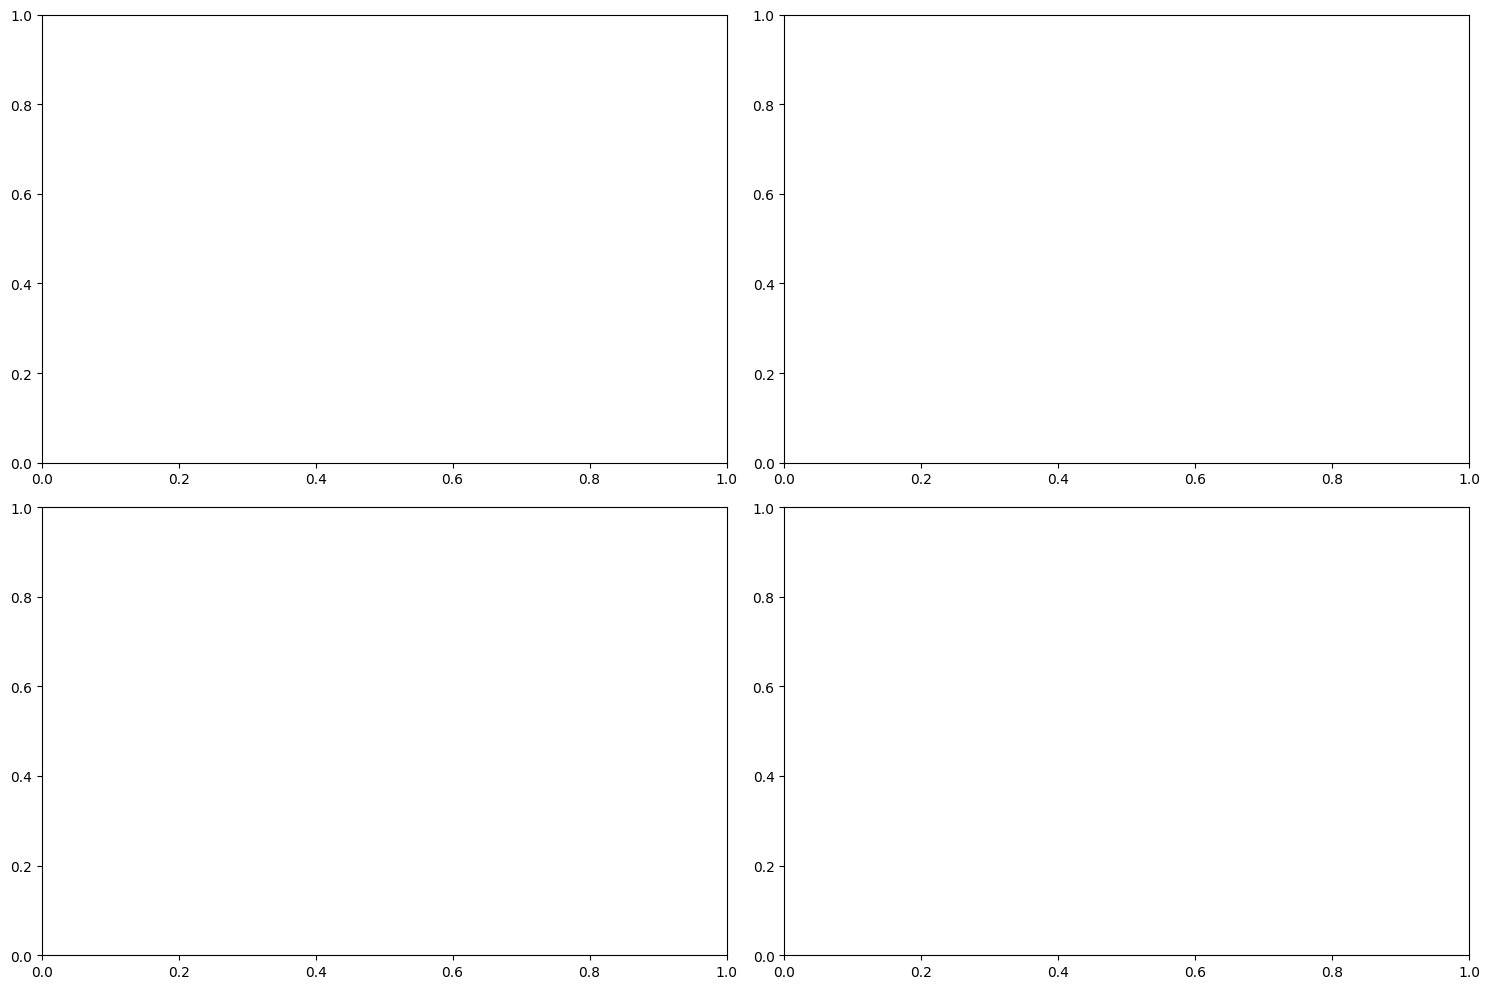

In [40]:

# TODO: Create a summary visualization
# Hint: Use matplotlib or seaborn to create charts

import matplotlib.pyplot as plt
import pandas as pd

# Convert results to DataFrame for easier analysis
df = pd.DataFrame(analysis_results)

# TODO: Create visualizations
# 1. Sentiment scores by category
# 2. Most common emotional adjectives
# 3. Action verbs frequency

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# TODO: Plot 1 - Sentiment by category
# YOUR CODE HERE

# TODO: Plot 2 - Word frequency analysis
# YOUR CODE HERE

# TODO: Plot 3 - Problem categorization
# YOUR CODE HERE

# TODO: Plot 4 - Urgency analysis
# YOUR CODE HERE

plt.tight_layout()
plt.show()



### 💼 Business Impact Questions:
1. How could this analysis help prioritize customer service tickets?
2. What patterns do you notice in different problem categories?
3. How might you automate the routing of calls based on POS analysis?
4. What are the limitations of this approach?



## ⚡ Lab Exercise 3: Tagger Performance Benchmarking (20 minutes)

Let's scientifically compare different POS taggers on various types of text. This will help you understand when to use which tool.


ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x7c04439680d0>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              ^^^^^^

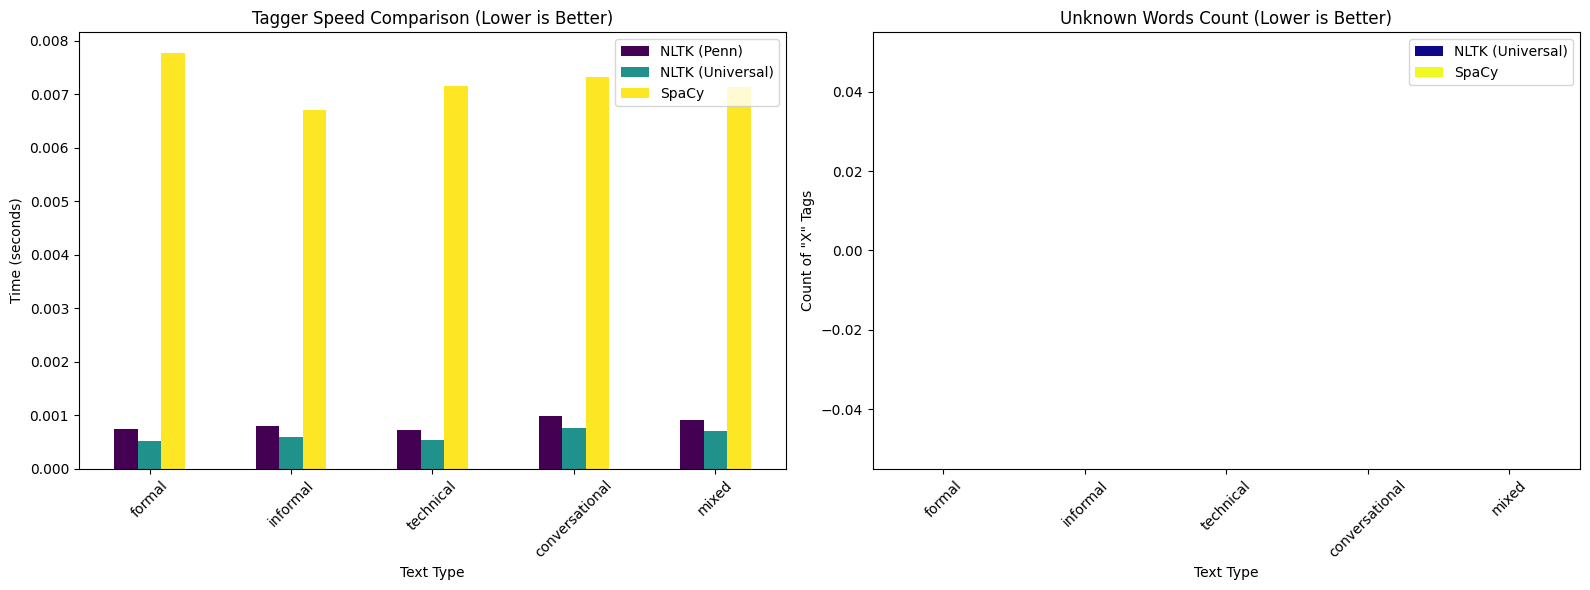

In [46]:
import time
from collections import defaultdict
import re

def remove_emojis(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # Emoticons
        "\U0001F300-\U0001F5FF"  # Miscellaneous Symbols and Pictographs
        "\U0001F680-\U0001F6FF"  # Transport and Map Symbols
        "\U0001F1E0-\U0001F1FF"  # Flags (iOS)
        "\U00002702-\U000027B0"  # Dingbats
        "\U000024C2-\U0001F251"  # Enclosed Alphanumerics, etc.
        "\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs (e.g., shrug emoji is here)
        "\u200d" # Zero Width Joiner
        "\ufe0f" # Variation Selector-16
        "]+", flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', text)

# Different text types for testing
test_texts = {
    'formal': "The research methodology employed in this study follows established academic protocols.",
    'informal': "lol this study is kinda weird but whatever works i guess ", # Removed emoji directly
    'technical': "The API returns a JSON response with HTTP status code 200 upon successful authentication.",
    'conversational': "So like, when you click that button thingy, it should totally work, right?",
    'mixed': "OMG the algorithm's performance is absolutely terrible! The accuracy dropped to 23% wtf"
}

# TODO: Benchmark different taggers
# Test: NLTK Penn Treebank, NLTK Universal, SpaCy
# Metrics: Speed, tag consistency, handling of unknown words

benchmark_results = defaultdict(dict)

for text_type, original_text in test_texts.items():
    cleaned_text = remove_emojis(original_text) # Clean text for SpaCy and printing

    print(f"\n\ud83e\uddea Testing {text_type.upper()} text:")
    print(f"Text: {cleaned_text}") # Print cleaned text
    print("-" * 60)

    # NLTK Penn Treebank timing
    start_time = time.time()
    nltk_penn_tokens = nltk.word_tokenize(original_text) # Use original for NLTK to see raw handling
    nltk_penn_tags = nltk.pos_tag(nltk_penn_tokens)
    nltk_penn_time = time.time() - start_time

    # NLTK Universal timing
    start_time = time.time()
    nltk_univ_tokens = nltk.word_tokenize(original_text) # Use original for NLTK to see raw handling
    nltk_univ_tags = nltk.pos_tag(nltk_univ_tokens, tagset='universal')
    nltk_univ_time = time.time() - start_time

    # SpaCy timing
    start_time = time.time()
    spacy_doc = nlp(cleaned_text) # Use cleaned text for SpaCy
    spacy_time = time.time() - start_time

    # Count unknown/problematic tags
    # For NLTK Universal, 'X' typically denotes an unknown/other category
    # For SpaCy, 'X' or sometimes 'SYM' or 'INTJ' can indicate problematic/non-standard words, but 'X' is the most direct.
    nltk_unknown = sum(1 for word, tag in nltk_univ_tags if tag == 'X')
    spacy_unknown = sum(1 for token in spacy_doc if token.pos_ == 'X')

    # Store results
    benchmark_results[text_type] = {
        'nltk_penn_time': nltk_penn_time,
        'nltk_univ_time': nltk_univ_time,
        'spacy_time': spacy_time,
        'nltk_unknown': nltk_unknown,
        'spacy_unknown': spacy_unknown
    }

    print(f"NLTK Penn time: {nltk_penn_time:.4f}s")
    print(f"NLTK Univ time: {nltk_univ_time:.4f}s")
    print(f"SpaCy time: {spacy_time:.4f}s")
    print(f"NLTK unknown words: {nltk_unknown}")
    print(f"SpaCy unknown words: {spacy_unknown}")

# Create performance comparison visualization
results_df = pd.DataFrame(benchmark_results).T

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plotting Speed
results_df[['nltk_penn_time', 'nltk_univ_time', 'spacy_time']].plot(kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('Tagger Speed Comparison (Lower is Better)')
axes[0].set_ylabel('Time (seconds)')
axes[0].set_xlabel('Text Type')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(['NLTK (Penn)', 'NLTK (Universal)', 'SpaCy'])

# Plotting Unknown Words
results_df[['nltk_unknown', 'spacy_unknown']].plot(kind='bar', ax=axes[1], colormap='plasma')
axes[1].set_title('Unknown Words Count (Lower is Better)')
axes[1].set_ylabel('Count of "X" Tags')
axes[1].set_xlabel('Text Type')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(['NLTK (Universal)', 'SpaCy'])

plt.tight_layout()
plt.show()


### 📊 Performance Analysis:
1. Which tagger is fastest? Does speed matter for your use case?
    **In here, the NLTK is the fastest of the two, both for Universal and Penn. Though in most cases, SpaCy is the fastest, and this speed's usefulness is porportional to its scale. If the tags are for a handful of documents for a class assignmetn or exploratory analysis, NLTK is perfectly adequate for its speed. However, if the tags are for thousands of lease agreements, well reports, or financial filings in a production pipeline, SpaCy's speed becomes critical.**
2. Which handles informal text best?
    **SpaCy handles informal text the better out of the two as it is trained on a broader and diverse copora that includes web text.**
3. How do the taggers compare on technical jargon?
    **Both generally struggle with technical jargon, though in different ways. As NLTK's tagger tends to default unknown technical terms as nouns, while SpaCy's models handle morphological patterns better and assign verb forms and derivations for unfamiliar words that may have that style.**
4. What trade-offs do you see between speed and accuracy?
    **The trade-offs between speed and accuracy applies in aspects like the statistical taggers for NLTK, and SpaCy's neural pipeline. As they have a moderate speed to compensate with their good accuracy.**


## 🚨 Lab Exercise 4: Edge Cases and Error Analysis (15 minutes)

Every system has limitations. Let's explore the edge cases where POS taggers struggle and understand why.


In [47]:
# Challenging edge cases
edge_cases = [
    "Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.",  # Famous ambiguous sentence
    "Time flies like an arrow; fruit flies like a banana.",              # Classic ambiguity
    "The man the boat the river.",                                       # Garden path sentence
    "Police police Police police police police Police police.",          # Recursive structure
    "James while John had had had had had had had had had had had a better effect on the teacher.",  # Had had had...
    "Can can can can can can can can can can.",                         # Modal/noun ambiguity
    "@username #hashtag http://bit.ly/abc123 ",                   # Social media elements - Removed emojis directly
    "COVID-19 AI/ML IoT APIs RESTful microservices",                    # Modern technical terms
]

import re

def remove_emojis(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # Emoticons
        "\U0001F300-\U0001F5FF"  # Miscellaneous Symbols and Pictographs
        "\U0001F680-\U0001F6FF"  # Transport and Map Symbols
        "\U0001F1E0-\U0001F1FF"  # Flags (iOS)
        "\U00002702-\U000027B0"  # Dingbats
        "\U000024C2-\U0001F251"  # Enclosed Alphanumerics, etc.
        "\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs (e.g., shrug emoji is here)
        "\u200d" # Zero Width Joiner
        "\ufe0f" # Variation Selector-16
        "]+", flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', text)

print("\ud83d\udea8 EDGE CASE ANALYSIS")
print("=" * 50)

# TODO: Process each edge case and analyze failures
for i, original_text in enumerate(edge_cases, 1):
    cleaned_text = remove_emojis(original_text) # Clean text for SpaCy and printing

    print(f"\n\ud83d\udd0d Edge Case {i}:")
    print(f"Text: {cleaned_text}") # Print cleaned text
    print("-" * 30)

    try:
        # Process with both taggers
        nltk_tokens = nltk.word_tokenize(original_text) # Use original for NLTK to see raw handling
        nltk_tags = nltk.pos_tag(nltk_tokens, tagset='universal')
        spacy_doc = nlp(cleaned_text) # Use cleaned text for SpaCy

        # Identify potential errors or weird tags
        # Look for: repeated tags, unusual patterns, X tags, etc.

        # Clean words from NLTK tags before printing to avoid UnicodeEncodeError
        cleaned_nltk_tags = [(remove_emojis(w), t) for w, t in nltk_tags]
        print("NLTK (Universal) tags:", cleaned_nltk_tags)
        print("SpaCy tags:", [(token.text, token.pos_) for token in spacy_doc])

        # Analyze what went wrong - simple analysis based on 'X' or unexpected tags
        nltk_problematic_words = [w for w, t in nltk_tags if t == 'X']
        spacy_problematic_words = [token.text for token in spacy_doc if token.pos_ == 'X']

        if nltk_problematic_words:
            print(f"  NLTK struggled with: {nltk_problematic_words} (tagged as 'X')")
        if spacy_problematic_words:
            print(f"  SpaCy struggled with: {spacy_problematic_words} (tagged as 'X')")

        # Further manual observation for common issues:
        if i == 1: # Buffalo buffalo
            print("  Analysis: Both taggers might struggle with the repeated use of 'buffalo' in different grammatical roles. NLTK often tags all as NOUN, while SpaCy might get some verbs right if its model is trained on such specific ambiguities.")
        elif i == 2: # Time flies
            print("  Analysis: This is a classic garden path sentence. 'flies' and 'fruit' can be verbs or nouns. Observe if taggers correctly distinguish.")
        elif i == 3: # The man the boat
            print("  Analysis: A syntactically valid but semantically unusual sentence. Expect taggers to assign NOUN to most words, potentially missing a verb if they expect one.")
        elif i == 6: # Can can can
            print("  Analysis: Ambiguity of 'can' as modal verb vs. noun (container). Check if taggers distinguish based on context.")
        elif i == 7: # Social media elements
            print("  Analysis: Expect 'X' tags or symbols for @username, #hashtag, URLs, and emojis as they are outside standard dictionary words.")
        elif i == 8: # Technical terms
            print("  Analysis: Modern technical terms might be tagged as NOUN or PROPN if recognized, or 'X' if completely unknown to the model's vocabulary.")


    except Exception as e:
        print(f"\u274c Error processing: {e}")

# TODO: Reflection on limitations
print("\n\ud83e\udde0 REFLECTION ON LIMITATIONS:")
print("=" * 40)
print("POS taggers, especially rule-based or statistical models, can struggle with several edge cases:")
print("1.  **Ambiguity**: Words like 'buffalo' or 'flies' that can function as multiple parts of speech depending on context. They rely heavily on surrounding words, which can be insufficient in highly ambiguous sentences.")
print("2.  **Novelty/Out-of-Vocabulary (OOV) Words**: Slang, emojis, URLs, hashtags, new technical jargon (e.g., 'COVID-19', 'microservices' if not in training data). These are often tagged as 'X' (unknown) or a generic noun/symbol.")
print("3.  **Syntactic Complexity/Garden Path Sentences**: Sentences that are grammatically correct but initially mislead the reader (or tagger) due to their structure, like 'The man the boat the river.'")
print("4.  **Repetitive Structures**: Sentences like 'Buffalo buffalo...' or 'had had had' where the same word is repeated with different functions, making contextual disambiguation very challenging.")
print("5.  **Informal/Conversational Language**: Disfluencies ('um', 'uh'), contractions, and highly informal phrasing often don't fit standard grammatical patterns, leading to errors or generic tags.")
print("6.  **Punctuation and Special Characters**: Often tokenized separately or cause issues, especially in social media text.")

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 28-29: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/zmq/eventloop/zmqstream.py", line 551, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 120, in _handle_event
    event_f()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_s


### 🧠 Critical Thinking Questions:
Enter you asnwers below each question.
1. Why do these edge cases break the taggers?

    **Edge cases can break the taggers because they intefere with their context dependency, cause ambiguity, are brone to out-of-vocabulary issues like new words and typos, fail when syntax deviates from the standard 'subject-verb-object' format, and struggle with unexpected punctuation and tokenization.**

2. How might you preprocess text to handle some of these issues?

    **I might need to improve the tokenizers or use smarter ones that handle contractions, hyphens, email addresses, URLs, and so on, rather than simply splitting the space. I also may need to convert the text to lowercase if the context allows for it, to reduce vocabulary size. I also need to correct spelling errors and typos, lemmatize the words to their base dictionary form, and handle out-of-vocabulary cases by breaking it into subwords, like splitting ('unfriednly') into ('un', 'friend', 'ly').**

3. When would these limitations matter in real applications?

    **These limitations matter in real applications in a couple of ways. For one, should these limitations misinterpret a situation or diagnosis as opposite to what it actually, such as mis-tagging a 'not' or 'left' as a noun instead of an adjective, it could potentially lead to wrong diagnoses and the consequences that come with that. Limitations can also affect the accuracy of search engines, as interpreting a word with many potential contexts, like ;bank', with the wrong one in relation to the words around it, renders the results irrelevant. Chatbots that fail to tag slang can make themselves sound incompetent or fail to understand the intent. And mist-agging parts of speech generally leads to grammatical errors in the output language.**

4. How do modern large language models handle these cases differently?

    **Modern large language models handle these cases differently through contextual embeddings and vast training data.**

---



## 🎯 Final Reflection and Submission

Congratulations! You've completed a comprehensive exploration of POS tagging, from basic concepts to real-world challenges.

### 📝 Reflection Questions (Answer in the cell below):

1. **Tool Comparison**: Based on your experience, when would you choose NLTK vs SpaCy? Consider factors like ease of use, accuracy, speed, and application type.

2. **Real-World Applications**: Describe a specific business problem where POS tagging would be valuable. How would you implement it?

3. **Limitations and Solutions**: What are the biggest limitations you discovered? How might you work around them?

4. **Future Learning**: What aspects of POS tagging would you like to explore further? (Neural approaches, custom training, domain adaptation, etc.)

5. **Integration**: How does POS tagging fit into larger NLP pipelines? What other NLP tasks might benefit from POS information?



### ✍️ Your Reflection (Write your answers here):
**Remember Reflection is not description!**

**1. Tool Comparison:**
I would go with SpaCy because of its speed and simplicity. While NLTK has a lot of comprehensive and helpful tools when it comes to NLP, because SpaCy is simpler and faster, it's much more scalable.
  
**2. Real-World Applications:**
A specific business problem where POS tagging would be valuable could be an automated contract, or lease analysis in real estate. By analyzing and extracting key clauses in the contract, one could save hundreds of hours of manual contract review per year.

**3. Limitations and Solutions:**
The vocabulary in default models is quite limited to news corpora with technical jargon. As such a tagger might mislabel "gross" in "gross working interest", or "play" in "exploration play" as different terms. Taggers also rely on context, which means short phrases or bullet points can reduce accuracy. Standard models don't really handle code-switching different languages, or non-standard English well. The solutions for each of these include fine-tuning or retraining the tagger on domain-specific data, provide additional context to phrases that don't have enough, and train on representative corpora or use multilingual models.

**4. Future Learning:**
Some areas that wouldn't hurt to exlpore would include transformer-based tagging, domain adaptation, and custom training pipelines in SpaCy v3.

**5. Integration:**
POS tagging fits into larger NLP Pipelines as it's a foundational layer that feeds into other NLP tasks like: Named Entity Recognition (NER), through distinguishing proper nouns, or entities, and common nouns; information extraction through identifying subject-verb-object triples for knowledge graphs; Dependency parsing;  senitment analysis; text summarization; question answering; and any other NLP tasks that require the knowledge of each word's part of speech to build upon their specialties.



---

## 📤 Submission Checklist

Before submitting your completed notebook, make sure you have:

- [ ] ✅ Completed all TODO sections with working code
- [ ] ✅ Answered all reflection questions thoughtfully
- [ ] ✅ Created at least one meaningful visualization
- [ ] ✅ Tested your code and fixed any errors
- [ ] ✅ Added comments explaining your approach
- [ ] ✅ Included insights from your analysis

### 📋 Submission Instructions:
1. **Save your notebook**: File → Save (or Ctrl+S)
2. **Download**: File → Download → Download .ipynb
3. **Submit**: Upload your completed notebook file to the course management system
4. **Filename**: Use format: `L05_LastName_FirstName_ITAI2373.ipynb or pdf`  

### 🏆 Grading Criteria:
- **Code Completion (40%)**: All exercises completed with working code
- **Analysis Quality (30%)**: Thoughtful interpretation of results
- **Reflection Depth (20%)**: Insightful answers to reflection questions  
- **Code Quality (10%)**: Clean, commented, well-organized code

---

## 🎉 Great Work!

You've successfully explored the fascinating world of POS tagging! You now understand how computers parse human language and can apply these techniques to solve real-world problems.


Keep exploring and happy coding! 🚀
